# Как устроено изображение в NumPy
В растовой графике ***цифровое изображение*** представляет собой матрицу размером ${H \times W \times C}$, где каждый элемент сопоставляется пикселю, ${H}$ - высота картинки в пикселях, ${W}$ - ширина, и ${C}$ - количество каналов изображения.

Количество каналов зависит от ***цветового представления***. То есть от того, как компьютер интерпретирует цвет пикселя (какое ***цветовое пространство*** он использует). Чаще всего количество каналов равно 3, реже 4, а иногда и 1 (для картинок в градациях серого). Наиболее популярна RGB модель, где каждый пиксель состоит из трех чисел, соответствующих красному (R), зеленому (G) и синему (B) цветам.

uint8 - восьмибитное изображение, значения 0–255 для каждого пикселя и канала.


In [16]:
import cv2

img_bgr = cv2.imread("C:/VSCode projects/cv_me/images/Cat_November_2010-1a.jpg") 

img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)  

img_gray = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)

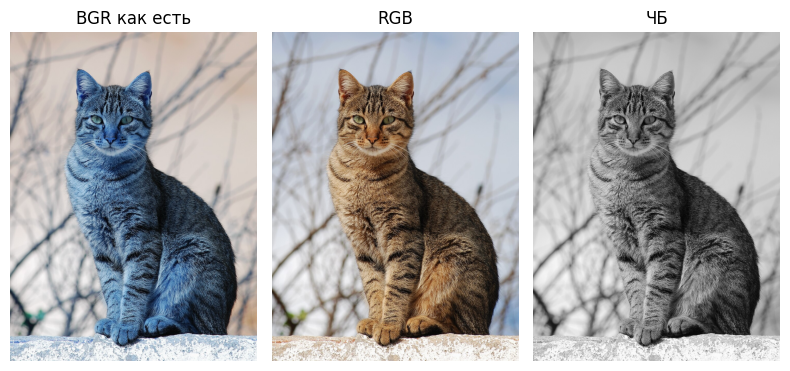

In [17]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(1, 3, figsize=(8, 4))

axs[0].imshow(img_bgr)
axs[0].set_title("BGR как есть")
axs[0].axis("off")

axs[1].imshow(img_rgb)
axs[1].set_title("RGB")
axs[1].axis("off")

axs[2].imshow(img_gray, cmap="gray")
axs[2].set_title("ЧБ")
axs[2].axis("off")

plt.tight_layout()
plt.show()

# Ключевые понятия

## `shape`

`img.shape` показывает размеры массива:

- Ч/б: `(H, W)`
- Цветное: `(H, W, 3)` или `(H, W, 4)` с альфой

## `dtype`

`img.dtype` — тип элементов массива.

Для изображений часто `uint8`, иногда `float32` или `float64` при нормализации.

Важно:

- Все арифметические операции с `uint8` надо аккуратно сопровождать `clip` и, при необходимости, преобразованием в `float` (иначе возможно переполнение).

In [18]:
print(img_bgr.shape)  
print(img_bgr.dtype)  

print(img_rgb.shape)  
print(img_rgb.dtype)  

print(img_gray.shape)  
print(img_gray.dtype)  

(1282, 960, 3)
uint8
(1282, 960, 3)
uint8
(1282, 960)
uint8


In [19]:
img_f64 = img_rgb.astype("float64")
print(img_f64.dtype)

float64


## `slicing` (срезы и индексация)

Срезы по осям: `img[y1:y2, x1:x2]` — классический crop.

Индексация каналов:

- `img[:, :, 0]` — красный канал
- `img[:, :, 1]` — зелёный канал
- `img[:, :, 2]` — синий канал

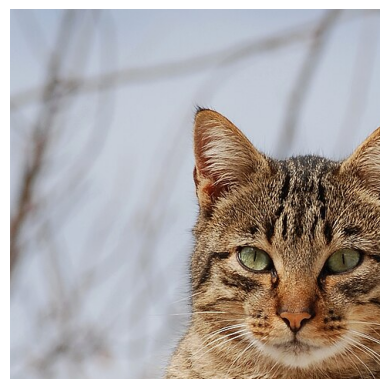

In [24]:
crop = img_rgb[20:500, 20:500]

plt.imshow(crop)
plt.axis("off")
plt.show()

In [25]:
r = img_rgb[:,:, 0]
g = img_rgb[:,:, 1]
b = img_rgb[:,:, 2]

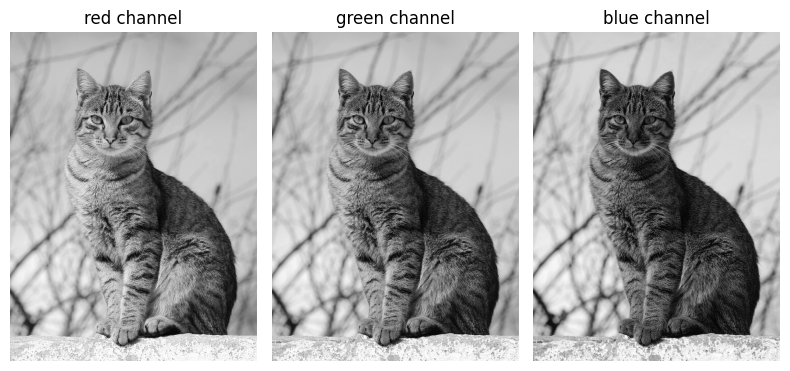

In [27]:
fig, axs = plt.subplots(1, 3, figsize=(8, 4))

axs[0].imshow(r, cmap="gray")
axs[0].set_title("red channel")
axs[0].axis("off")

axs[1].imshow(g, cmap="gray")
axs[1].set_title("green channel")
axs[1].axis("off")

axs[2].imshow(b, cmap="gray")
axs[2].set_title("blue channel")
axs[2].axis("off")

plt.tight_layout()
plt.show()

## `broadcasting`

Broadcasting — правило, по которому NumPy “растягивает” массивы разных размеров, чтобы выполнить поэлементную операцию. Добавление или умножение маски, а также вектора из 3 элементов к RGB-изображению, тоже использует broadcasting.

In [44]:
import numpy as np

img_1 = (img_rgb - img_rgb.min()) / (img_rgb.max() - img_rgb.min())

img_2 = img_rgb * np.array([1.2, 0.8, 1.0])

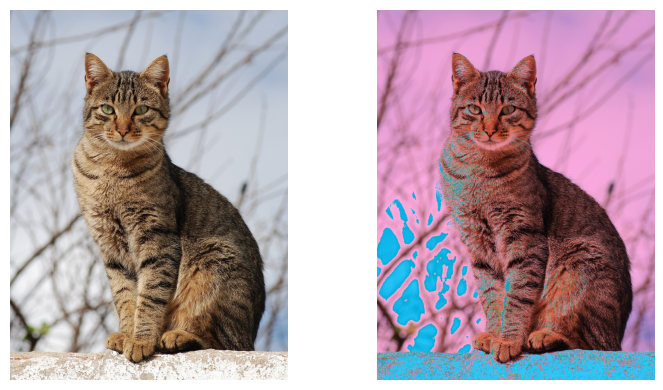

In [45]:
fig, axs = plt.subplots(1, 2, figsize=(8, 4))

axs[0].imshow(img_1)
axs[0].axis("off")

axs[1].imshow(img_2.astype("uint8"))
axs[1].axis("off")

plt.tight_layout()
plt.show()

## `Rotate` (поворот)

```python
rot = np.rot90(img, k=1)
```

Это поворот на 90° против часовой стрелки.

При этом `shape` меняется местами по высоте и ширине.

In [48]:
img_90 = np.rot90(img_rgb, k=1)
img_180 = np.rot90(img_rgb, k=2)
img_270 = np.rot90(img_rgb, k=3)

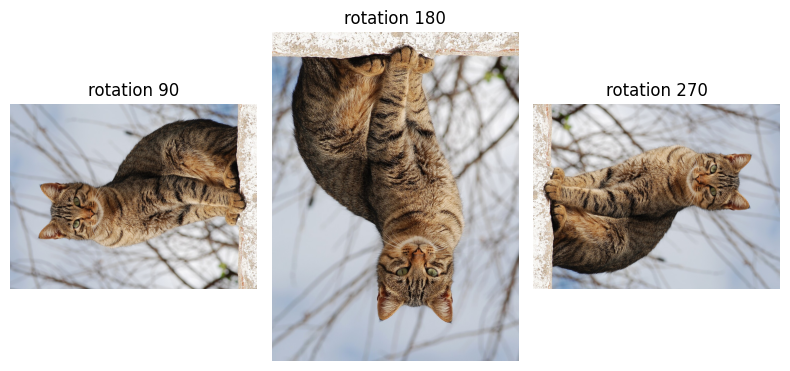

In [49]:
fig, axs = plt.subplots(1, 3, figsize=(8, 4))

axs[0].imshow(img_90)
axs[0].set_title("rotation 90")
axs[0].axis("off")

axs[1].imshow(img_180)
axs[1].set_title("rotation 180")
axs[1].axis("off")

axs[2].imshow(img_270)
axs[2].set_title("rotation 270")
axs[2].axis("off")

plt.tight_layout()
plt.show()

## `Resize` (масштабирование)

Чистым NumPy это можно сделать через срезы или шаги — например, как жёсткий downsample.

Это не “красивый” resize с интерполяцией, но хорошо показывает связь `shape` и индексации.

In [50]:
i2 = img_rgb[::2, ::2, :]
i4 = img_rgb[::4, ::4, :]
i8 = img_rgb[::8, ::8, :]

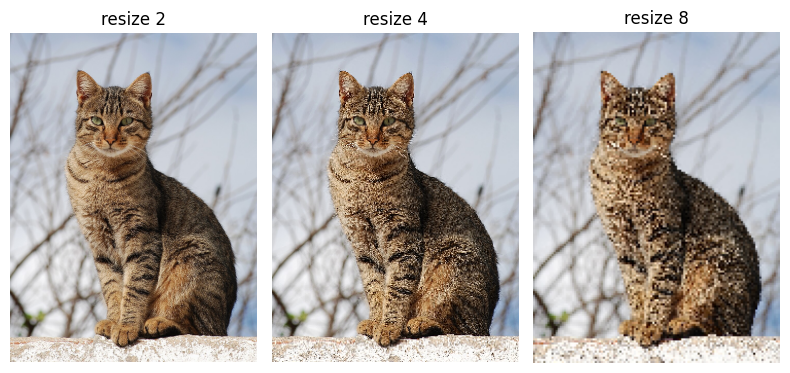

In [51]:
fig, axs = plt.subplots(1, 3, figsize=(8, 4))

axs[0].imshow(i2)
axs[0].set_title("resize 2")
axs[0].axis("off")

axs[1].imshow(i4)
axs[1].set_title("resize 4")
axs[1].axis("off")

axs[2].imshow(i8)
axs[2].set_title("resize 8")
axs[2].axis("off")

plt.tight_layout()
plt.show()

### 8. Histogram

Гистограмма — это распределение значений яркости.

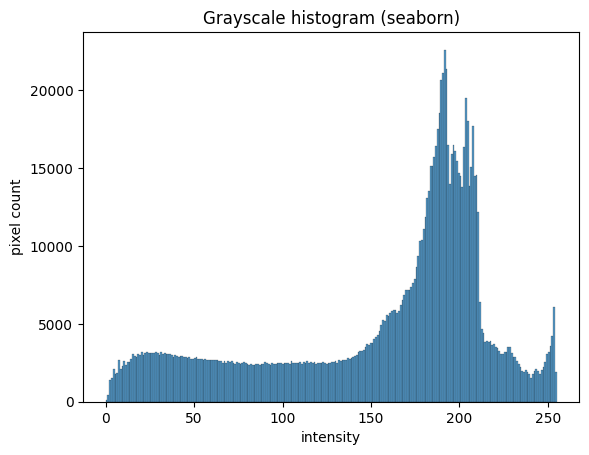

In [53]:
import seaborn as sns

sns.histplot(img_gray.flatten(), bins=256, kde=False)
plt.xlabel("intensity")
plt.ylabel("pixel count")
plt.title("Grayscale histogram (seaborn)")
plt.show()